In [1]:
from functools import partial

import gc

import marimo as mo
import pandas as pd
import polars as pl
import altair as alt
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(
    style="white", palette="RdYlGn", font="BlexMono Nerd Font Mono"
)
SEED = 171205

def ctheme():
    return {
        "config": {
            "theme": "powerbi",
            "background": "#ffffff",
            # "font": "Inter, system-ui, sans-serif",
            "font": " BlexMono Nerd Font Mono",
            "autosize": {"type": "fit", "contains": "padding"},
            "title": {
                "color": "#111111",
                "font": "Inter, system-ui, sans-serif",
                "fontSize": 16,
                "fontWeight": "bold",
                "anchor": "middle",
                "offset": 10,
            },
            "view": {
                "height": 450,
                "width": 800,
                "stroke": "transparent",
            },
            "axis": {
                "labelColor": "#333333",
                "titleColor": "#111111",
                "labelFontSize": 12,
                "titleFontSize": 14,
                "gridColor": "#e5e5e5",
                "labelAngle": -45,
            },
        }
    }

# alt.data_transformers.enable("vegafusion")
alt.themes.register("ctheme", ctheme)
alt.theme.enable("ctheme")

/tmp/ipykernel_90361/3738090637.py:39: AltairDeprecationWarning: 
Deprecated since `altair=5.5.0`. Use altair.theme instead.
Most cases require only the following change:

    # Deprecated
    alt.themes.enable('quartz')

    # Updated
    alt.theme.enable('quartz')

If your code registers a theme, make the following change:

    # Deprecated
    def custom_theme():
        return {'height': 400, 'width': 700}
    alt.themes.register('theme_name', custom_theme)
    alt.themes.enable('theme_name')

    # Updated
    @alt.theme.register('theme_name', enable=True)
    def custom_theme():
        return alt.theme.ThemeConfig(
            {'height': 400, 'width': 700}
        )

See the updated User Guide for further details:
    https://altair-viz.github.io/user_guide/api.html#theme
    https://altair-viz.github.io/user_guide/customization.html#chart-themes
  alt.themes.register("ctheme", ctheme)


ThemeRegistry.enable('ctheme')

In [3]:
df = pd.read_parquet("../data/raw/sample_data.parquet")
df

,id,collected_time,create_time,desc,duet_display,duet_enabled,duet_info_duet_from_id,is_ad,item_comment_status,item_mute,...,user_verified,challenges,music_id,music_title,music_album,music_author_name,music_duration,music_original,music_play_url,url
5261844,7494763464758447391,2025-04-19 07:29:24.316806+02,1745010612,د خوست ولایت ځنګلونه وهل کیږي. دا له هیواد او ...,0,t,0.0,f,0,f,...,f,"[""\u062e\u0648\u0633\u062a"",""khost"",""foryou"",""...",7.494763e+18,original sound,None,Sawabdin Makhkash,47.0,t,https://v16m.tiktokcdn-us.com/463209334c49a3f0...,https://tiktok.com/@/video/7494763464758447391
9576919,7511866366102736159,2025-06-08 00:48:02.858824+02,1748992703,May Book Reviews. My Vela Scarves stay on with...,0,t,0.0,f,0,f,...,f,"[""bookrecs"",""bookrecs\ud83d\udcda"",""mayreads"",...",7.381496e+18,Manifestation,Manifestation,"Perfect, so dystopian",209.0,f,https://sf19.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7511866366102736159
1206048,7464714642925833514,2025-05-10 02:05:26.979636+02,1738014361,#فالكونز #عامر,0,t,0.0,f,0,f,...,f,"[""\u0641\u0627\u0644\u0643\u0648\u0646\u0632"",...",7.464715e+18,original sound,None,يزن / فالكونز,61.0,t,https://v16m.tiktokcdn-us.com/a983793c01f8b22f...,https://tiktok.com/@/video/7464714642925833514
6206188,7496524243140840750,2025-04-24 00:59:54.226993+02,1745420580,#therealeannise #sassysexysilverfox #over50 #d...,0,t,0.0,f,0,f,...,f,"[""therealeannise"",""sassysexysilverfox"",""over50...",6.786264e+18,Diamonds Are Forever (From Diamonds Are Forever),James Bond Hits,The Soundtrack Tribute Band,60.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7496524243140840750
8146649,7473638697523498286,2025-04-03 01:27:19.848352+02,1740092129,"Breastfeeding as a birth control method? Tips,...",0,f,0.0,f,0,f,...,f,"[""breastfeeding"",""birthconrol"",""lam"",""breastfe...",7.473639e+18,original sound,None,Kelley✨| SAHM of 3 ☀️🌸🌼| RN,156.0,t,https://v16m.tiktokcdn-us.com/151a979ce8da2be5...,https://tiktok.com/@/video/7473638697523498286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149232,7493072688697675026,2025-04-14 19:33:33.789667+02,1744616943,Membalas kepada @albert.amores Welcome to skyd...,0,t,0.0,f,0,f,...,f,"[""jump"",""adventure"",""zipline"",""extreme"",""landi...",7.272591e+18,original sound - MAN KINABALU,None,MAN KINABALU,46.0,t,https://v19.tiktokcdn-us.com/86da7ec271225c8ab...,https://tiktok.com/@/video/7493072688697675026
3168914,7371591000453598506,2025-04-25 18:46:05.622946+02,1716332285,barry’s bootcamp chewed me up i will stick to ...,0,t,0.0,f,0,f,...,f,"[""barrys"",""barrysbootcamp"",""la"",""lagym"",""lafit...",7.360319e+18,original sound,None,eh,11.0,t,https://v16m.tiktokcdn-us.com/985bc483bfe48ff4...,https://tiktok.com/@/video/7371591000453598506
9565563,7491520338543512862,2025-04-10 11:52:42.557293+02,1744255527,the cutest video you'll ever see #tiktok #fyp...,0,t,0.0,f,0,f,...,f,"[""tiktok"",""fyp"",""trending"",""viral"",""foryoupage...",7.491520e+18,original sound,None,Clips4Daiz♤,45.0,t,https://v16m.tiktokcdn-us.com/f7a1777ed259fce4...,https://tiktok.com/@/video/7491520338543512862
2816629,7428835082322103598,2025-05-06 08:13:30.937582+02,1729660467,@Sabrina Carpenter dedicating Juno to @Millie ...,0,t,0.0,f,0,f,...,f,"[""shortnsweet"",""sabrinacarpenter"",""shortnsweet...",7.428835e+18,original sound,None,Savannah,293.0,t,https://v77.tiktokcdn.com/158845d8d018d8098bdf...,https://tiktok.com/@/video/7428835082322103598


# Data shape y quality

In [4]:
print(f"shape: {df.shape}")
print(df.columns)

shape: (2000000, 55)
Index(['id', 'collected_time', 'create_time', 'desc', 'duet_display',
       'duet_enabled', 'duet_info_duet_from_id', 'is_ad',
       'item_comment_status', 'item_mute', 'item_control_can_repost',
       'official_item', 'original_item', 'share_enabled', 'playlist_id',
       'stitch_display', 'stitch_enabled', 'diversification_id', 'stats_time',
       'collect_count', 'comment_count', 'digg_count', 'play_count',
       'share_count', 'vq_score', 'duration', 'share_cover', 'poi_id',
       'poi_name', 'address', 'city', 'city_code', 'country_code',
       'poi_category', 'father_poi_id', 'father_poi_name', 'poi_tt_type_code',
       'poi_tt_type_name_medium', 'poi_tt_type_name_super',
       'poi_tt_type_name_tiny', 'user_id', 'user_avatar_larger',
       'user_avatar_medium', 'user_avatar_thumb', 'user_tt_seller',
       'user_verified', 'challenges', 'music_id', 'music_title', 'music_album',
       'music_author_name', 'music_duration', 'music_original',
      

In [5]:
df.dtypes

id                           int64
collected_time              object
create_time                  int64
desc                        object
duet_display                 int64
duet_enabled                object
duet_info_duet_from_id     float64
is_ad                       object
item_comment_status          int64
item_mute                   object
item_control_can_repost     object
official_item               object
original_item               object
share_enabled               object
playlist_id                float64
stitch_display               int64
stitch_enabled              object
diversification_id         float64
stats_time                  object
collect_count                int64
comment_count                int64
digg_count                   int64
play_count                   int64
share_count                  int64
vq_score                   float64
duration                     int64
share_cover                 object
poi_id                       int64
poi_name            

## Tipos de datos

Con solo ver los primeros registros del conjunto de datos, así como los nombres de las características y los tipos de datos, podemos observar que es necesario realizar algunas conversiones en algunas variables; por ejemplo, `is_ad` claramente está pensada para ser un valor booleano o `create_time` y similares que deberia de ser un datetime, pero se almacena como cadena.

In [6]:
df.isna().sum()

id                               0
collected_time                   0
create_time                      0
desc                         23702
duet_display                     0
duet_enabled                     0
duet_info_duet_from_id        1003
is_ad                            0
item_comment_status              0
item_mute                     1003
item_control_can_repost          0
official_item                    0
original_item                    0
share_enabled                    0
playlist_id                1878903
stitch_display                   0
stitch_enabled                   0
diversification_id          221874
stats_time                       0
collect_count                    0
comment_count                    0
digg_count                       0
play_count                       0
share_count                      0
vq_score                         0
duration                         0
share_cover                      0
poi_id                           0
poi_name            

In [7]:
_df = (
    df.isna()
    .mean()
    .rename_axis("column")
    .reset_index(name="null_proportion")
)
alt.Chart(_df).mark_bar().encode(
    x=alt.X(
        "column:N",
        sort=None,
        title="column",
        axis=alt.Axis(labelAngle=-90),
    ),
    y="null_proportion",
).properties(title="proporcion de nulos por variable")

alt.Chart(...)

In [8]:
df.isna().any(axis=1).mean()

np.float64(0.996652)

## Valores faltantes

A primera vista, la mayoría de las variables tienen un porcentaje marginal de valores faltantes; sin embargo, si solo contamos los registros que no tienen ningún valor faltante, terminamos con menos del 1 % de nuestros datos, por lo que se necesita algún tipo de interpolación. Suponemos que bastará con interpolar las features numéricas, además de considerar que probablemente la mayoría de las features, como `addres, user_avatar_large, url, etc.` seran con alta probabilidad dropeadas a la hora del modelado, ya sea por cuestiones de privacidad de leakeage o por falta de relevancia.

In [9]:
print(f"proporcion de duplicados {df['id'].duplicated().mean()}")
df.loc[df["id"].duplicated()]

proporcion de duplicados 0.000386


,id,collected_time,create_time,desc,duet_display,duet_enabled,duet_info_duet_from_id,is_ad,item_comment_status,item_mute,...,user_verified,challenges,music_id,music_title,music_album,music_author_name,music_duration,music_original,music_play_url,url
6946949,7498634340759391506,2025-04-29 23:32:55.134062+02,1745911865,#foryou #adele #mylove #safeplace #fire #bigwa...,0,t,0.0,f,0,f,...,f,"[""foryou"",""adele"",""mylove"",""safeplace"",""fire"",...",6.777274e+18,Pieces (Solo Piano Version),None,Danilo Stankovic,85.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7498634340759391506
9401392,7457325236070010142,2025-04-23 21:58:27.675029+02,1736293850,XXX - ? Floor 555 #trap #trapmetal #rap #xxx ...,0,t,0.0,f,0,f,...,f,"[""trap"",""trapmetal"",""rap"",""xxx"",""emo"",""hiphop""...",5.000000e+18,NUMB,?,XXXTENTACION,30.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7457325236070010142
1602123,7256106368673828138,2025-05-09 01:13:49.463147+02,1689443929,In 4 days…we turn Paso into a partyyyyy 🤠🎶🎡 #M...,0,t,0.0,f,0,f,...,f,"[""midstatefair"",""pasorobles"",""california"",""fyp""]",6.777274e+18,Ocean Breeze,None,Danilo Stankovic,65.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7256106368673828138
7991154,7439028570896207134,2025-05-28 02:53:46.917548+02,1732033822,Fall harvest is our favorite! 🌽,0,t,0.0,f,0,f,...,f,[],6.704931e+18,God Gave Me You,Red River Blue (Deluxe Edition),Blake Shelton,60.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7439028570896207134
4952900,7159101856478711086,2025-05-24 06:50:53.632447+02,1666858405,Mother Gothel's Rapunzel Flowers 🏵#diy #props ...,0,t,0.0,f,0,f,...,f,"[""DIY"",""props"",""mothergothel"",""rapunzel"",""rapu...",5.000000e+18,Something That I Want,Tangled,Grace Potter,30.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7159101856478711086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3681211,7498774741394771246,2025-06-10 14:30:03.909555+02,1745944564,BTS of Texas Chi Omega Recruitment Team Photos...,0,t,0.0,f,0,f,...,f,"[""fyp"",""foryou"",""chiomega"",""chio"",""txchiomega""...",5.000000e+18,It Never Rains in Southern California,It Never Rains In Southern California,Albert Hammond,30.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7498774741394771246
579554,7447236594928520490,2025-05-31 14:30:29.580342+02,1733944896,Now I just need to cut my daughter’s hair real...,0,f,0.0,f,0,f,...,f,"[""doratheexplorer"",""backpack"",""packwithme"",""pa...",5.000000e+18,"Backpack, Backpack!",Dora The Explorer,Dora The Explorer,24.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7447236594928520490
5018286,7400012735003528490,2025-04-18 15:57:49.392208+02,1722949740,"A kingfisher, a skilled aerial hunter, uses it...",0,t,0.0,f,0,f,...,f,"[""wildlifewithamber"",""kingfisher"",""beltedkingf...",6.777274e+18,Pieces (Solo Piano Version),None,Danilo Stankovic,85.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7400012735003528490
2600175,7502041174832581934,2025-05-09 05:08:00.721144+02,1746705091,Rescue a family dog 🙏🙏🙏🙏❤️❤️❤️❤️❤️#rescue #res...,0,t,0.0,f,0,f,...,f,"[""rescue"",""rescueanimals"",""rescuedog"",""dog"",""a...",6.777274e+18,Ocean Breeze,None,Danilo Stankovic,65.0,f,https://sf16.tiktokcdn-us.com/obj/tos-alisg-ve...,https://tiktok.com/@/video/7502041174832581934


## Duplicados

podemos observar que existe una cantidad muy pequeña de valores duplicados (comparados con el id). Por lo que dropearlos es una decision aceptable.

# Analisis estadistico de los datos

A continuacion exploramos distribuciones y un pequeño analisis descriptivo

## Preprocesamiento discreto

Antes de comenzar a analizar los datos haremos un  preprocesamiento muy discreto que consiste casi unicamente en cambiar los tipos de datos a los correctos para poder analizarlos.

In [10]:
BOOLEAN_FEATURES = [
    "duet_enabled",
    "is_ad",
    "item_mute",
    "item_control_can_repost",
    "official_item",
    "original_item",
    "share_enabled",
    "stitch_enabled",
    "music_original",
]
DATETIME_VARIABLES = [
    # "create_time" # Probablemente no sea usada por cuestiones de leakage
]
NOMINAL_FEATURES = [
    "desc",
    "address",
    "poi_name",
    "city",
    "city_code",
    "country_code",
    "poi_category",
    "poi_tt_type_code",
    "poi_tt_type_name_medium",
    "poi_tt_type_name_super",
    "poi_tt_type_name_tiny",
    "challenges",
    "music_id",
    "music_title",
    "music_album",
    "duet_info_duet_from_id",
    "music_author_name",
    "poi_id",
    "diversification_id",
    "item_comment_status",
]
NUMERICAL_FEATURES = [
    "music_duration",
    "vq_score",
    "duration",
    "stitch_display",
    "duet_display",
]

POST_STATISTICS_FEATURES = [
    "share_count",
    "play_count",
    "digg_count",
    "comment_count",
    "collect_count",
]
TARGET = "play_count"

Se separaron las `NUMERICAL_FEATURES` de las `POST_STATISTICS_FEATURES` debido a que por las razones explicadas en `informe-final.ipynb` las estadisticas de interacciones del post son candidatos o en su defecto material para el target

In [11]:
_bool_mapping = {"t": True, "f": False}
boolean_features_df = (
    df[BOOLEAN_FEATURES]
    .copy(deep=True)
    .dropna()
    .map(lambda x: _bool_mapping.get(x))
    .astype("bool")
)
boolean_features_df

,duet_enabled,is_ad,item_mute,item_control_can_repost,official_item,original_item,share_enabled,stitch_enabled,music_original
5261844,True,False,False,True,False,False,True,True,True
9576919,True,False,False,True,False,False,True,True,False
1206048,True,False,False,True,False,False,True,True,True
6206188,True,False,False,True,False,False,True,True,False
8146649,False,False,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...
3149232,True,False,False,True,False,False,True,True,True
3168914,True,False,False,True,False,False,True,True,True
9565563,True,False,False,True,False,False,True,True,True
2816629,True,False,False,True,False,False,True,True,True


### Analisis de Dummies

In [12]:
_df = (
    boolean_features_df.mean()
    .reset_index()
    .rename(columns={"index": "column", 0: "proportion_1s"})
)

_c1 = (
    alt.Chart(_df)
    .mark_bar()
    .encode(x="column", y="proportion_1s")
    .properties(title="balance de variables booleanas")
)
_c2 = (
    alt.Chart()
    .mark_rule(
        color="salmon",
        strokeDash=[
            4,
            4,
        ],
        size=1,
    )
    .encode(y=alt.datum(0.5))
)
_c1 + _c2

alt.LayerChart(...)

En general podemos ver que las variables doomies tal como estan no estan para nada balanceadas, esto puede ser un problema en el entrenamiento y tiene que ser tomado en cuenta a la hora del preprocesamiento.

### comparacion con el target

a continuacion vamos a comparar las distribuciones del target respecto a cada variable dummie. Como se mostro en las celdas anteriores, se usara para el analisis de forma preliminar `play_count`

In [13]:
boolean_df = pd.concat([boolean_features_df, df[[TARGET]]], axis=1)
boolean_df

,duet_enabled,is_ad,item_mute,item_control_can_repost,official_item,original_item,share_enabled,stitch_enabled,music_original,play_count
5261844,True,False,False,True,False,False,True,True,True,2455
9576919,True,False,False,True,False,False,True,True,False,359
1206048,True,False,False,True,False,False,True,True,True,113638
6206188,True,False,False,True,False,False,True,True,False,479
8146649,False,False,False,True,False,False,True,False,True,1353
...,...,...,...,...,...,...,...,...,...,...
109291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1325386
2959925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11648
2860086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89134
1351645,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56400


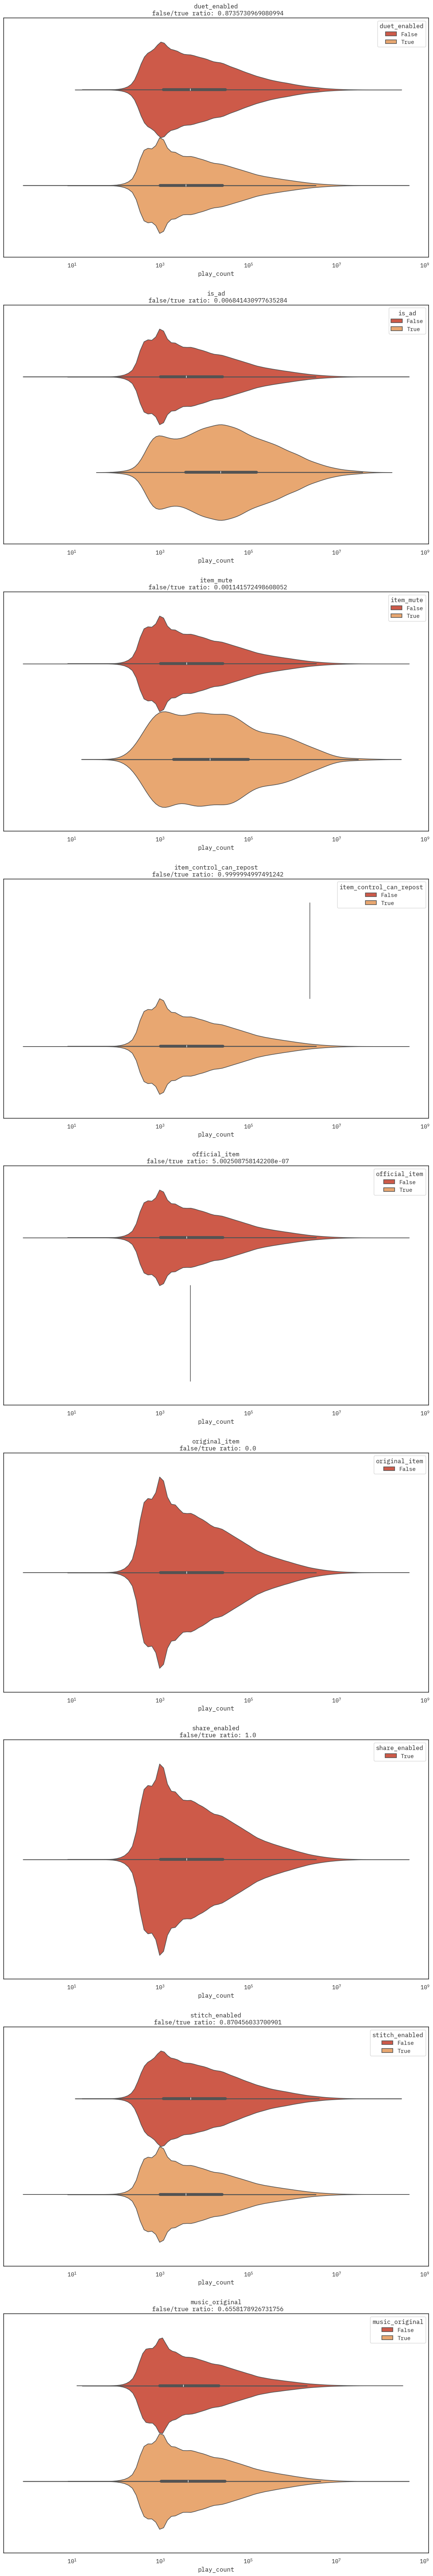

<Figure size 640x480 with 0 Axes>

In [14]:
_, ax = plt.subplots(
    nrows=len(BOOLEAN_FEATURES),
    ncols=1,
    figsize=(15, 10 * len(BOOLEAN_FEATURES)),
)
ax = ax.flatten()
for i1, dummie_col in enumerate(BOOLEAN_FEATURES):
    sns.violinplot(
        boolean_df, x=TARGET, hue=dummie_col, ax=ax[i1], log_scale=True
    )
    ax[i1].set_title(
        f"{dummie_col}\n false/true ratio: {boolean_df[dummie_col].mean()}"
    )
plt.show()
plt.tight_layout()

A primera vista los resultados no son alentadores, las distribuciones lucen muy similares, y las que tienen diferencias mas marcadas son en aquellas variables donde las clases estan sumamente desbalanceadas.


### Variables Nominales

A continuacion haremos un analisis somero y superficial de las variables Nominales que pueden tener mucha mas variedad de valores, como por ejemplo `desc`, el analisis sera superficial debido a que al tratarse variables de texto pueden llegar a requerir tecnicas de feature engineering mas sofisticadas. Por lo que lo dejamos para mas delante.

In [15]:
# df[["city", "city_code"]]
nom_df_ = df[NOMINAL_FEATURES].copy(deep=True)
nom_df_

,desc,address,poi_name,city,city_code,country_code,poi_category,poi_tt_type_code,poi_tt_type_name_medium,poi_tt_type_name_super,poi_tt_type_name_tiny,challenges,music_id,music_title,music_album,duet_info_duet_from_id,music_author_name,poi_id,diversification_id,item_comment_status
5261844,د خوست ولایت ځنګلونه وهل کیږي. دا له هیواد او ...,North America,United States,None,4273359.0,6252001,Place and Address,19a3a1,Places,Place and Address,Country,"[""\u062e\u0648\u0633\u062a"",""khost"",""foryou"",""...",7.494763e+18,original sound,None,0.0,Sawabdin Makhkash,22535865200907089,10083.0,0
9576919,May Book Reviews. My Vela Scarves stay on with...,"Chicago, IL, United States","Chicago, Lake Michigan",Chicago,4887398.0,6252001,Outdoors and Traveling,08a1b2,Natural Attraction,Outdoors and Traveling,Lake,"[""bookrecs"",""bookrecs\ud83d\udcda"",""mayreads"",...",7.381496e+18,Manifestation,Manifestation,0.0,"Perfect, so dystopian",21568226288236304,10014.0,0
1206048,#فالكونز #عامر,North America,United States,None,4273359.0,6252001,Place and Address,19a3a1,Places,Place and Address,Country,"[""\u0641\u0627\u0644\u0643\u0648\u0646\u0632"",...",7.464715e+18,original sound,None,0.0,يزن / فالكونز,22535865200907089,10075.0,0
6206188,#therealeannise #sassysexysilverfox #over50 #d...,"Texas, United States",Dallas,None,4684904.0,6252001,Place and Address,19a3a0,Places,Place and Address,City,"[""therealeannise"",""sassysexysilverfox"",""over50...",6.786264e+18,Diamonds Are Forever (From Diamonds Are Forever),James Bond Hits,0.0,The Soundtrack Tribute Band,22535865206966264,10029.0,0
8146649,"Breastfeeding as a birth control method? Tips,...",North America,United States,None,4273359.0,6252001,Place and Address,19a3a1,Places,Place and Address,Country,"[""breastfeeding"",""birthconrol"",""lam"",""breastfe...",7.473639e+18,original sound,None,0.0,Kelley✨| SAHM of 3 ☀️🌸🌼| RN,22535865200907089,10018.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149232,Membalas kepada @albert.amores Welcome to skyd...,"4125 162nd St, Flushing, United States",Hainan,Queens,5117472.0,6252001,Food and Drink,05a3a1,Specialty Dining,Food and Drink,Chinese Restaurant,"[""jump"",""adventure"",""zipline"",""extreme"",""landi...",7.272591e+18,original sound - MAN KINABALU,None,0.0,MAN KINABALU,20319181082341098,10058.0,0
3168914,barry’s bootcamp chewed me up i will stick to ...,"1331 Havenhurst Dr, Los Angeles, United States",Barry's Bootcamp,Los Angeles,5368361.0,6252001,Recreation and Sport,21a3b4,Sport,Recreation and Sport,Gym,"[""barrys"",""barrysbootcamp"",""la"",""lagym"",""lafit...",7.360319e+18,original sound,None,0.0,eh,22535796876894500,10061.0,0
9565563,the cutest video you'll ever see #tiktok #fyp...,"2901 Trawick Rd, Wake, North Carolina 27604-37...",United Skates of America,Raleigh,4487042.0,6252001,Recreation and Sport,21a3b9,Sport,Recreation and Sport,Ice Skating Rink,"[""tiktok"",""fyp"",""trending"",""viral"",""foryoupage...",7.491520e+18,original sound,None,0.0,Clips4Daiz♤,21568226262434064,10017.0,0
2816629,@Sabrina Carpenter dedicating Juno to @Millie ...,"1 State Farm Dr, Atlanta, GA 30303, United States",State Farm Arena,Atlanta,4180439.0,6252001,Recreation and Sport,21a3c7,Sport,Recreation and Sport,Other Sport,"[""shortnsweet"",""sabrinacarpenter"",""shortnsweet...",7.428835e+18,original sound,None,0.0,Savannah,22535865215020589,10046.0,0


In [16]:
nom_df_.isna().mean()

desc                       1.185100e-02
address                    5.000000e-07
poi_name                   0.000000e+00
city                       6.291630e-01
city_code                  1.500000e-06
country_code               0.000000e+00
poi_category               0.000000e+00
poi_tt_type_code           0.000000e+00
poi_tt_type_name_medium    0.000000e+00
poi_tt_type_name_super     0.000000e+00
poi_tt_type_name_tiny      2.753250e-02
challenges                 0.000000e+00
music_id                   9.520000e-04
music_title                2.615000e-04
music_album                6.874905e-01
duet_info_duet_from_id     5.015000e-04
music_author_name          2.160500e-03
poi_id                     0.000000e+00
diversification_id         1.109370e-01
item_comment_status        0.000000e+00
dtype: float64

Ahora recordamos que city es una de las variables con mayor cantidad de valores nulosm no obstante existe la variable `city_code` que apenas tiene  nulos, solo nos queda verificar que en efecto estas dos variables nos dicen la misma informacion

In [17]:
city_crosstab = pd.crosstab(
    nom_df_["city"], nom_df_["city_code"], normalize="index"
)

# silly code para poder ordenar todas las columnas en descending no encontre otra forma al menos que le entendiera
(city_crosstab * -1).transform(np.sort).abs()

city_code,3520339.0,3522551.0,4046255.0,4046274.0,4046332.0,4046430.0,4047204.0,4047734.0,4048023.0,4048094.0,...,116030103.0,116030107.0,116030114.0,116030120.0,116030122.0,116030123.0,116030127.0,116030132.0,116030133.0,116030134.0
city,,,,,,,,,,,,,,,,,,,,,
Abbeville,1.0,1.0,1.0,1.0,0.021786,1.0,0.000326,0.5,0.928571,0.083333,...,1.0,1.0,1.0,1.0,1.0,1.0,0.039604,0.666667,1.0,1.0
Abbeville County,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
Abbotsford,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
Abbottstown,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
Aberdeen,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zionsville,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
Zoe,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
Zortman,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0


Text(0.5, 1.0, 'suma de las columnas de crosstab \ncity vs city_code')

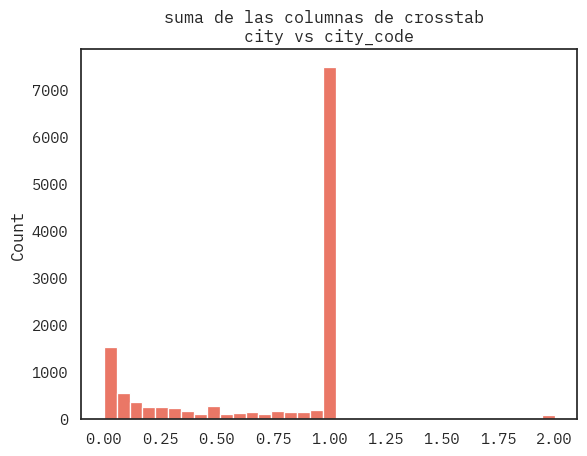

In [18]:
# city_crosstab.sum(axis=1)
# city_crosstab.sum()

sns.histplot(city_crosstab.sum())
plt.title("suma de las columnas de crosstab \ncity vs city_code")

Text(0.5, 1.0, 'histograma del numero de diferentes ciudades\nasociadas a un mismo city_code')

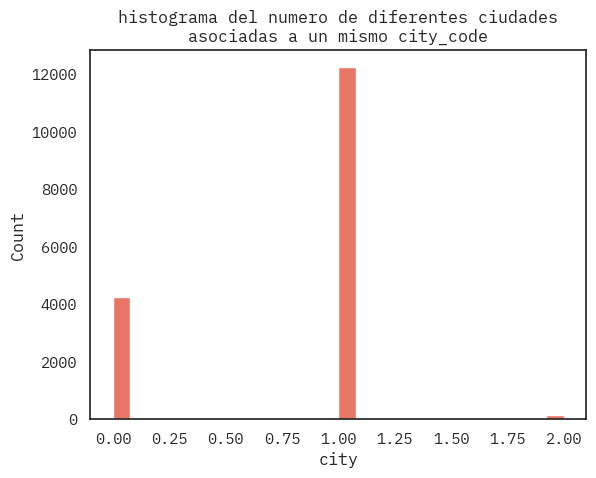

In [19]:
sns.histplot(
    nom_df_.groupby("city_code")["city"]
    .nunique()
    .sort_values(ascending=False),
)
plt.title(
    "histograma del numero de diferentes ciudades\nasociadas a un mismo city_code"
)

El resultado es a decir verdad postivo, ambos de estos graficos nos cuentan una historia similar y nos dicen basicamente que a efectos practicos `city` y `city_code` son colineares, evidentemente que los resultados son un tanto diferentes si conmutamos la comparacion, debido a que en una hay mas de la mitad de nulos. Viendo los datos linea por linea evidentemente no es tan sencillo, por ejemplo aquellas `city_code` con mas de una ciudad, que se muestra que existen en ambos graficos, no obstante siendo una proporcion relativamente pequeña lo consideramos  suficiente para dropear `city` y trabajar unicamente con `city_code`

In [20]:
_df = (
    nom_df_.nunique()
    .reset_index()
    .rename(columns={"index": "column", 0: "Distinct_count"})
)
alt.Chart(_df).mark_bar().encode(
    x="column", y="Distinct_count"
).properties(title="cadenas diferentes por columna")

alt.Chart(...)

una de las cosas que salta mucho a la vista es la gran diferencia entre `music_title` y `music_id` uno podria llegar a pensar que deberian de ser similares, la hipotesis es que puede haber una buena cantidad de canciones diferentes con el mismo titulo, aun asi vale la pena investigar

veamos cuales son aquellas columnas que tienen menos granularidad en sus filas

In [21]:
nom_df_.nunique().sort_values(ascending=True)

country_code                     1
item_comment_status              2
poi_tt_type_name_super          12
poi_category                    12
diversification_id              90
poi_tt_type_name_medium        110
poi_tt_type_name_tiny          355
poi_tt_type_code               364
duet_info_duet_from_id        3583
city                          9104
city_code                    16660
music_album                  82425
address                     123970
poi_name                    133621
poi_id                      149922
music_title                 157515
music_author_name           602757
music_id                   1122131
challenges                 1797306
desc                       1948097
dtype: int64

A primera instancia si queremos analizar algo como la media condicional vemos que a lo sumo hay 5 variables utiles, desde `poi_category` hasta `poi_tt_type_code`. es decir 364 clases para 2,000,000 de datos  o 10,000,000 en el dataset completo, todavia puede contarnos algo. Mas de 1,000 entradas diferentes necesitan algun otro tipo de feature engineering par que nos sean de utilidad, y en su defeto `country_code es inutil`.

Otra cosa que vale la pena mirar, es analizar la colinearidad entre `poi_category, poi_tt_type_name_super` y `poi_tt_type_name_tiny, poi_tt_type_code` debido a que tienen granularidades muy similares

In [22]:
_df = (
    nom_df_.groupby("poi_category")["poi_tt_type_name_super"]
    .nunique()
    .reset_index()
    .rename(
        columns={
            "poi_tt_type_name_super": "distinct_poi_tt_type_name_super_count"
        }
    )
)
alt.Chart(_df).mark_bar().encode(
    y="distinct_poi_tt_type_name_super_count", x="poi_category"
).properties(title="colinearidad  poi_category vs poi_tt_type_name_super ")

alt.Chart(...)

In [23]:
_table = pd.crosstab(
    nom_df_["poi_category"],
    nom_df_["poi_tt_type_name_super"],
    normalize=True,
)

(_table * -1).transform(np.sort).abs()

poi_tt_type_name_super,Education,Food and Drink,Health,Hotels and Lodging,Office and Industrial,Other,Outdoors and Traveling,Place and Address,Recreation and Sport,Residential,Service,Shopping
poi_category,,,,,,,,,,,,
Education,0.013626,0.049869,0.004715,0.012372,0.020592,0.024645,0.093042,0.638001,0.078673,0.001765,0.031364,0.031335
Food and Drink,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Health,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Hotels and Lodging,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Office and Industrial,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Other,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Outdoors and Traveling,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Place and Address,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Recreation and Sport,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [24]:
# poi_tt_type_name_tiny, poi_tt_type_code
_df = (
    nom_df_.groupby("poi_tt_type_name_tiny")["poi_tt_type_code"]
    .nunique()
    .reset_index()
    .rename(columns={"poi_tt_type_code": "distinct_poi_tt_type_code"})
)
alt.Chart(_df).mark_bar().encode(
    y="distinct_poi_tt_type_code", x="poi_tt_type_name_tiny"
).properties(title="colinearidad  poi_category vs poi_tt_type_name_super ")

alt.Chart(...)

In [25]:
_table = pd.crosstab(
    nom_df_["poi_tt_type_name_tiny"],
    nom_df_["poi_tt_type_code"],
    normalize=True,
)

(_table * -1).transform(np.sort).abs()

poi_tt_type_code,05a0a0,05a0a1,05a0a2,05a0a3,05a0a4,05a1a0,05a1a1,05a1a2,05a1a3,05a2a0,...,21a3b9,21a3c0,21a3c1,21a3c2,21a3c3,21a3c4,21a3c5,21a3c6,21a3c7,21a4a0
poi_tt_type_name_tiny,,,,,,,,,,,,,,,,,,,,,
ATM,0.005855,0.000188,0.000084,0.003396,0.00052,0.001696,0.000245,0.000919,0.002464,0.000459,...,0.010143,0.000601,0.000229,0.00001,0.000191,0.00002,0.000069,0.000012,0.024277,0.000621
Airport,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Amusement Park,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Aquarium,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Aquatic Center,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Water Park,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Waterfall,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
Windmill,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


`poi_category, poi_tt_type_name_super` y `poi_tt_type_name_tiny, poi_tt_type_code` son colineares por los que deberiamos de quedarnos solamente con una por cada par

In [26]:
nom_cols_to_drop = [
    "city",
    "poi_tt_type_name_super",
    "poi_tt_type_code",
    "country_code",
]
nom_df = nom_df_.drop(columns=nom_cols_to_drop)
nom_df

,desc,address,poi_name,city_code,poi_category,poi_tt_type_name_medium,poi_tt_type_name_tiny,challenges,music_id,music_title,music_album,duet_info_duet_from_id,music_author_name,poi_id,diversification_id,item_comment_status
5261844,د خوست ولایت ځنګلونه وهل کیږي. دا له هیواد او ...,North America,United States,4273359.0,Place and Address,Places,Country,"[""\u062e\u0648\u0633\u062a"",""khost"",""foryou"",""...",7.494763e+18,original sound,None,0.0,Sawabdin Makhkash,22535865200907089,10083.0,0
9576919,May Book Reviews. My Vela Scarves stay on with...,"Chicago, IL, United States","Chicago, Lake Michigan",4887398.0,Outdoors and Traveling,Natural Attraction,Lake,"[""bookrecs"",""bookrecs\ud83d\udcda"",""mayreads"",...",7.381496e+18,Manifestation,Manifestation,0.0,"Perfect, so dystopian",21568226288236304,10014.0,0
1206048,#فالكونز #عامر,North America,United States,4273359.0,Place and Address,Places,Country,"[""\u0641\u0627\u0644\u0643\u0648\u0646\u0632"",...",7.464715e+18,original sound,None,0.0,يزن / فالكونز,22535865200907089,10075.0,0
6206188,#therealeannise #sassysexysilverfox #over50 #d...,"Texas, United States",Dallas,4684904.0,Place and Address,Places,City,"[""therealeannise"",""sassysexysilverfox"",""over50...",6.786264e+18,Diamonds Are Forever (From Diamonds Are Forever),James Bond Hits,0.0,The Soundtrack Tribute Band,22535865206966264,10029.0,0
8146649,"Breastfeeding as a birth control method? Tips,...",North America,United States,4273359.0,Place and Address,Places,Country,"[""breastfeeding"",""birthconrol"",""lam"",""breastfe...",7.473639e+18,original sound,None,0.0,Kelley✨| SAHM of 3 ☀️🌸🌼| RN,22535865200907089,10018.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3149232,Membalas kepada @albert.amores Welcome to skyd...,"4125 162nd St, Flushing, United States",Hainan,5117472.0,Food and Drink,Specialty Dining,Chinese Restaurant,"[""jump"",""adventure"",""zipline"",""extreme"",""landi...",7.272591e+18,original sound - MAN KINABALU,None,0.0,MAN KINABALU,20319181082341098,10058.0,0
3168914,barry’s bootcamp chewed me up i will stick to ...,"1331 Havenhurst Dr, Los Angeles, United States",Barry's Bootcamp,5368361.0,Recreation and Sport,Sport,Gym,"[""barrys"",""barrysbootcamp"",""la"",""lagym"",""lafit...",7.360319e+18,original sound,None,0.0,eh,22535796876894500,10061.0,0
9565563,the cutest video you'll ever see #tiktok #fyp...,"2901 Trawick Rd, Wake, North Carolina 27604-37...",United Skates of America,4487042.0,Recreation and Sport,Sport,Ice Skating Rink,"[""tiktok"",""fyp"",""trending"",""viral"",""foryoupage...",7.491520e+18,original sound,None,0.0,Clips4Daiz♤,21568226262434064,10017.0,0
2816629,@Sabrina Carpenter dedicating Juno to @Millie ...,"1 State Farm Dr, Atlanta, GA 30303, United States",State Farm Arena,4180439.0,Recreation and Sport,Sport,Other Sport,"[""shortnsweet"",""sabrinacarpenter"",""shortnsweet...",7.428835e+18,original sound,None,0.0,Savannah,22535865215020589,10046.0,0


In [27]:
nominal_barcount_charts = []

for nom_col in nom_df:
    # 1. Preparar el DataFrame con orden descendente y calcular la proporción acumulada
    hist_df_ = (
        nom_df[nom_col]
        .value_counts()
        .sort_values(ascending=False)
        .rename_axis("string")
        .reset_index(name="count")
    )

    # Ojiva acumulada (0 a 1)
    hist_df_["cum_prop"] = (
        hist_df_["count"].cumsum() / hist_df_["count"].sum()
    )

    hist_df = hist_df_.head(40)  # Top 40 categorías

    bars = (
        alt.Chart(hist_df)
        .mark_bar(color="#4c78a8")
        .encode(
            x=alt.X(
                "string:N",
                sort=None,
                title=nom_col,
                axis=alt.Axis(labelAngle=-45),
            ),
            y=alt.Y("count:Q", title="Conteo"),
        )
    )

    line = (
        alt.Chart(hist_df)
        .mark_line(color="salmon", point=False)
        .encode(
            x=alt.X("string:N", sort=None),
            y=alt.Y(
                "cum_prop:Q",
                title="Proporción Acumulada",
                scale=alt.Scale(domain=[0, 1]),
                axis=alt.Axis(format="%"),
            ),
        )
    )

    chart = (
        alt.layer(bars, line)
        .resolve_scale(y="independent")
        .properties(title=f"Conteo y Ojiva de {nom_col}")
    )

    nominal_barcount_charts.append(chart)

alt.vconcat(*nominal_barcount_charts)

alt.VConcatChart(...)

Las interpretaciones de los graficos arrojan los diferentes resultados, aunque `desc` tenga un histograma con una clase dominante, hay demasiada variedad, cosa que ya veiamos desde el grafico anterior `address` es una variable mas manejable, con un codo de pareto mas definido, esto entre otras cosas nos sirve para establecer un threshold y definir una label `other` para los demas valores, otras variables con las que masomenos podriamos hacer algo similar son `city_code` `poi_tt_type_name_medium`, `poi_tt_type_name_tiny` y `diversification_id`



### Analisis de variables numericas

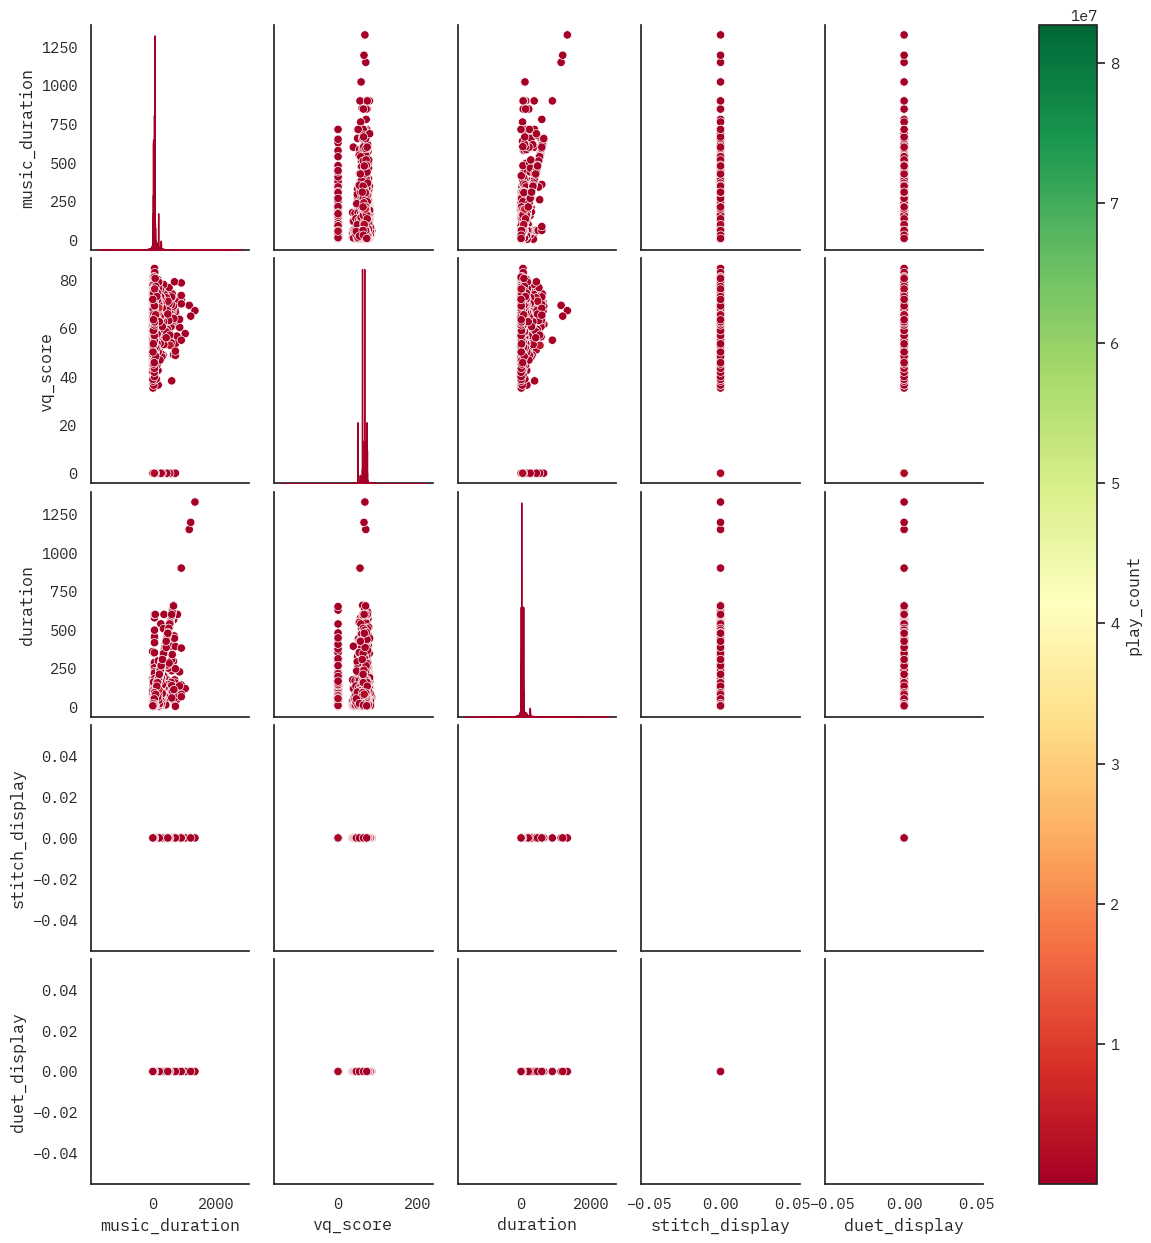

In [28]:
num_df = df[NUMERICAL_FEATURES + [TARGET]]
num_sample = num_df.sample(10_000, random_state=SEED)

c = sns.pairplot(num_sample, hue=TARGET, palette="RdYlGn")

c._legend.remove()

_norm = plt.Normalize(num_sample[TARGET].min(), num_sample[TARGET].max())
_sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=_norm)

c.fig.colorbar(_sm, ax=c.axes, orientation="vertical", label=TARGET)
c

In [29]:
num_df.describe()

,music_duration,vq_score,duration,stitch_display,duet_display,play_count
count,1.998007e+06,2.000000e+06,2.000000e+06,2000000.0,2000000.0,2.000000e+06
mean,7.388583e+01,6.135880e+01,5.383057e+01,0.0,0.0,1.515614e+05
std,9.300165e+01,1.738680e+01,8.009247e+01,0.0,0.0,1.255213e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,1.000000e+00
25%,2.700000e+01,6.103000e+01,1.400000e+01,0.0,0.0,1.020000e+03
50%,6.000000e+01,6.619000e+01,2.900000e+01,0.0,0.0,3.996000e+03
75%,6.800000e+01,6.979000e+01,6.200000e+01,0.0,0.0,2.635100e+04
max,3.600000e+03,9.318000e+01,3.600000e+03,0.0,0.0,3.425708e+08


/nix/store/2ark8i00cgv3lknrjyw34d753494y2ap-python3-3.13.13-env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/nix/store/2ark8i00cgv3lknrjyw34d753494y2ap-python3-3.13.13-env/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


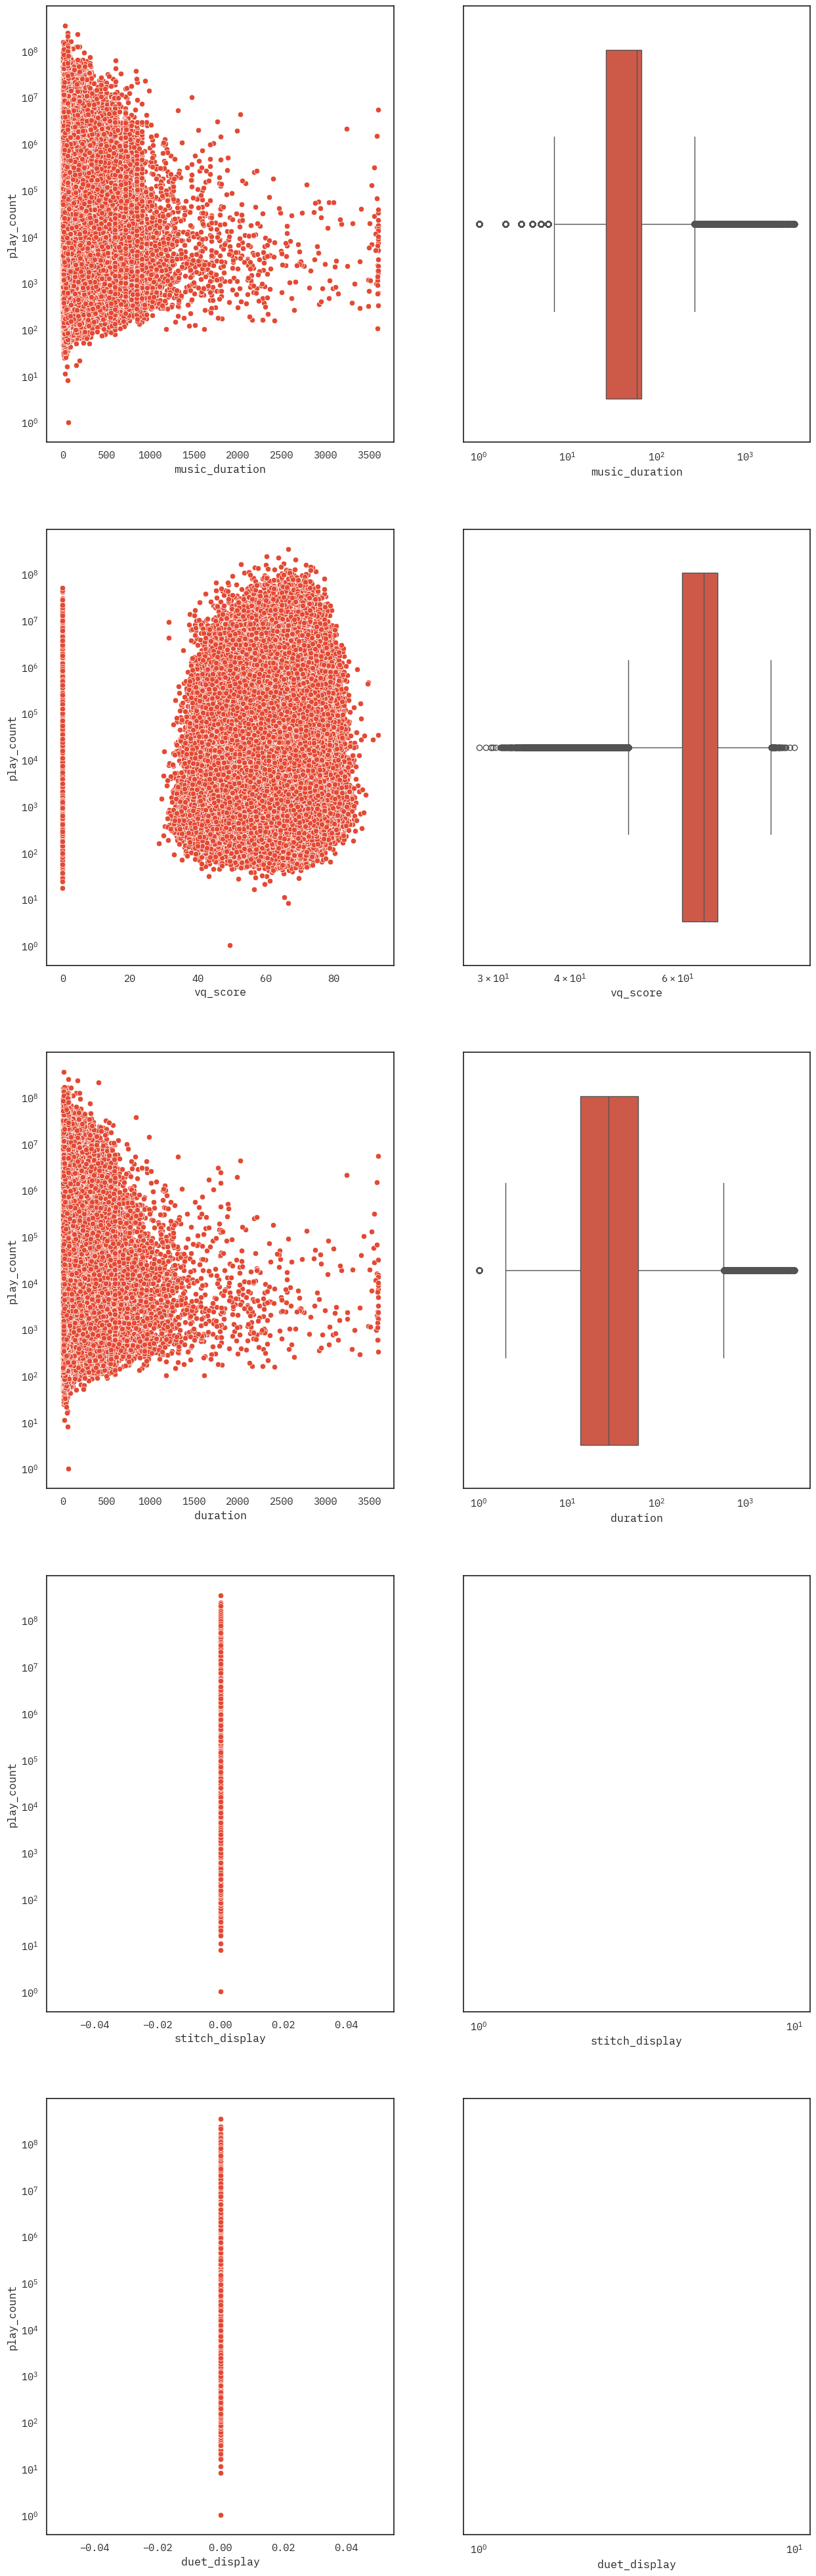

In [30]:
_, ax1 = plt.subplots(
    nrows=len(NUMERICAL_FEATURES),
    ncols=2,
    figsize=(15, 10 * len(NUMERICAL_FEATURES)),
)

ax1 = ax1.flatten()

for i2, num_col in enumerate(NUMERICAL_FEATURES):
    sns.scatterplot(num_df, x=num_col, y=TARGET, ax=ax1[i2 * 2])
    sns.boxplot(num_df, x=num_col, ax=ax1[i2 * 2 + 1], log_scale=True)
    ax1[i2 * 2].set_yscale("log")
plt.show()

In [31]:
# para chequear que duet y stitch display tienen un solo valor

alt.data_transformers.enable("vegafusion")

_cols = ["duet_display", "stitch_display"]

alt.hconcat(
    *[
        alt.Chart(num_df[[c]])
        .mark_bar()
        .encode(x=alt.X(c, bin=True), y="count()")
        .properties(title=f"histograma de {c}")
        for c in _cols
    ]
)

ImportError: The "vegafusion" data transformer and chart.transformed_data feature requires
version 2.0.3 or greater of the 'vegafusion' package.
This can be installed with pip using:
    pip install "vegafusion>=2.0.3"
or conda:
    conda install -c conda-forge "vegafusion>=2.0.3"

ImportError: vegafusion

alt.HConcatChart(...)

In [32]:
num_cols_to_drop = ["stitch_display", "duet_display"]
num_df_ = num_df.drop(columns=num_cols_to_drop)

Text(0.5, 1.0, 'histplot de play_count\nskew:52.512657422924455')

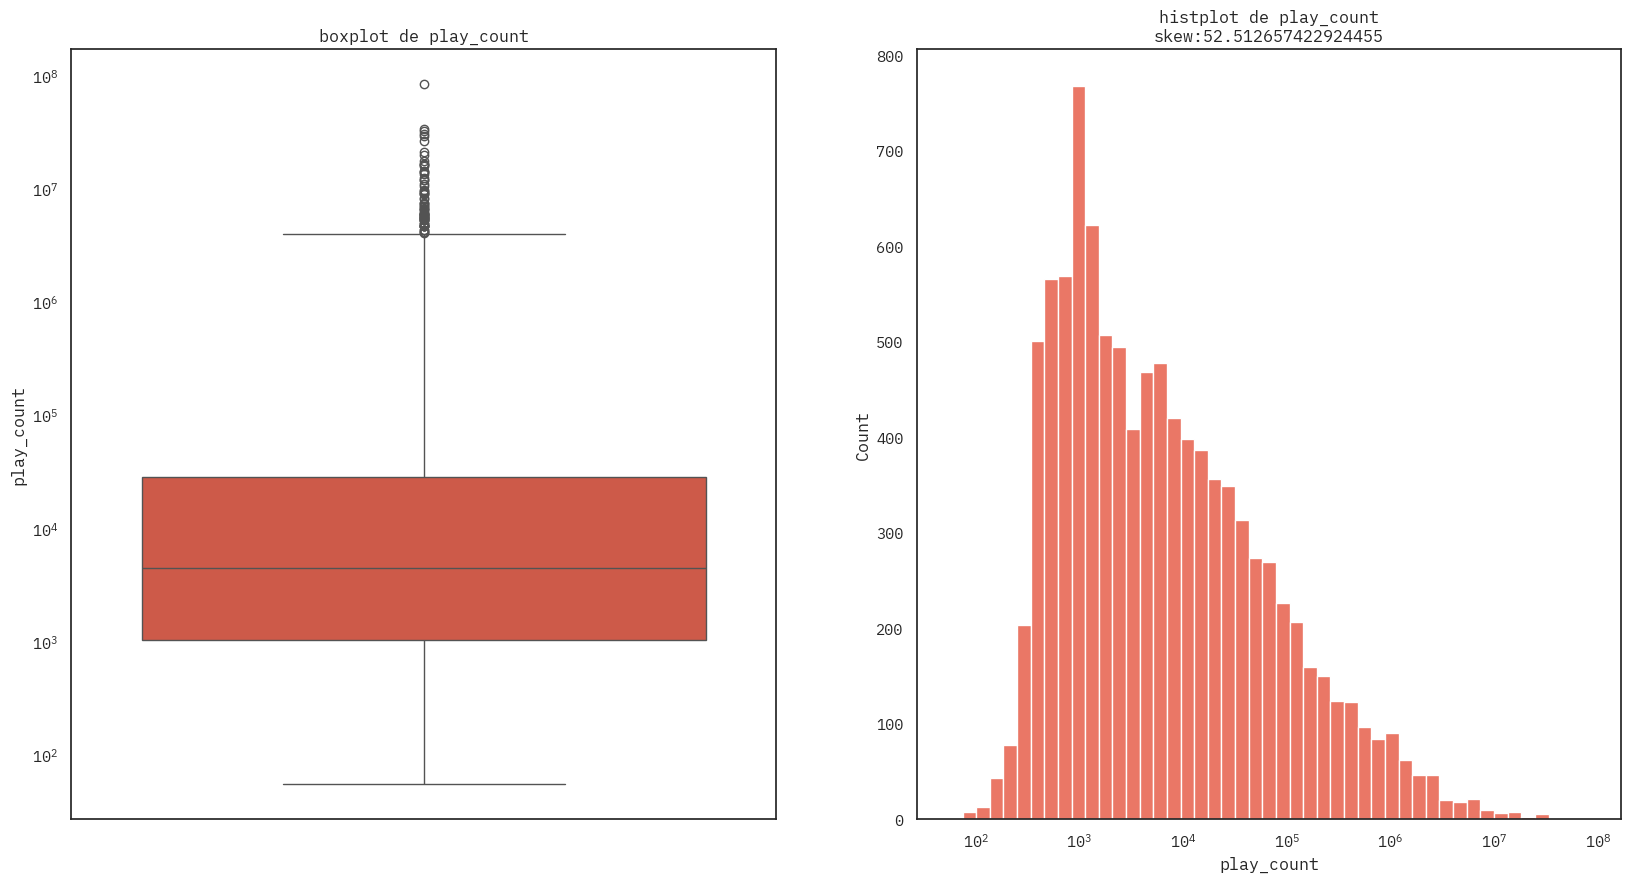

In [33]:
alt.data_transformers.enable("default")

_, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

sns.boxplot(num_sample[TARGET], log_scale=True, ax=ax2[0])
sns.histplot(num_sample[TARGET], log_scale=True, ax=ax2[1])
ax2[0].set_title("boxplot de play_count")
ax2[1].set_title(f"histplot de play_count\nskew:{num_df[TARGET].skew()}")

<Axes: >

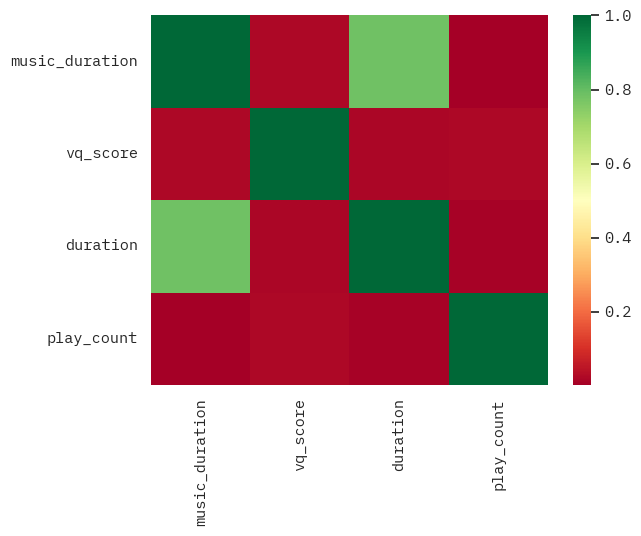

In [34]:
sns.heatmap(num_df_.corr(), cmap="RdYlGn")

Este pequeño analisis nos indica tambien que otras variables podemos tratar o debemos dropear. Lo Primero y mas evidente es que probablemente busquemos modelar al final $\ln(y)$ o $y^\lambda$ debido a que sino nos quedamos con un target con demasiados outliers. Por otro lado tambien revela que debemos de dropear `duet_display, stitch_display` y que hay oportunidad para discretizar o crear una nueva variable `no_vq` para intentar tratar aquellos donde `vq_score` es 0, por otro lado tenemos una correlacion alta entre `duration` y `music_duration` un tema que hay que cuidar si de casualidad se usa modelos lineales con interpretacion sobre los $w$ de las features, aunque de primeras luce complicado que un modelo lineal ajuste bien

# Conclusion

Siendo concisos nos encontramos con un dataset relativamente limpio con muchos metadatos y datos de caracter nominal o variables de texto con mucha granularidad. Pocas Features numericas y sin relacion aparente con el target, el target es una variable con alta varianza y desviacion estandar alta y bastante sesgada.


Lo que sigue a continuacion es  una preparacion de los datos sumamente conservadora, tales como imputacion de nulos dropear variables

si quisieramos ser mas especificos los pasos a seguir serian los siguientes

1. Dropear las variables

["stitch_display", "duet_display","city","poi_tt_type_name_super","poi_tt_type_code","country_code"]


y quedarnos solamente con
```
BOOLEAN_FEATURES = [
    "duet_enabled",
    "is_ad",
    "item_mute",
    "item_control_can_repost",
    "official_item",
    "original_item",
    "share_enabled",
    "stitch_enabled",
    "music_original",
]
NOMINAL_FEATURES = [
    "desc",
    "address",
    "poi_name",
    "city_code",
    "poi_category",
    "poi_tt_type_name_medium",
    "poi_tt_type_name_tiny",
    "challenges",
    "music_id",
    "music_title",
    "music_album",
    "duet_info_duet_from_id",
    "music_author_name",
    "poi_id",
    "diversification_id",
    "item_comment_status",
]
NUMERICAL_FEATURES = [
    "music_duration",
    "vq_score",
    "duration",
]

TARGET = "play_count"
```


2. cambiar a los tipos de dato correctos

boolean_features -> astype(bool)
*id -> object / category

3. imputacion de datos numericos segun la estrategia recomendada por la literatura

4. dropear la cantidad marginal de nulos restantes